# Trust Rank Assignment Code
Below is the complete Python code for the Trust Rank assignment. 
**Team Members Roll Numbers:**
- **Roll Number 1:** CE22BTECH11010
- **Roll Number 2:** CE22BTECH11006
- **Roll Number 3:** CE22BTECH11031 

In [1]:
# Global parameters for trust score computation
ALPHA = 0.85
CONVERGENCE_TOLERANCE = 1e-6

## Load input data

In [2]:
import pandas as pd
payment_data = pd.read_csv("Transactions.csv")
fraudulent_accounts_data = pd.read_csv("badAccounts.csv")
print("Payment Data Sample:")
print(payment_data.head())
print("\nFraudulent Accounts Sample:")
print(fraudulent_accounts_data.head())

Payment Data Sample:
   Sender  Receiver  Amount
0    1309      1011  123051
1    1309      1011  118406
2    1309      1011  112456
3    1309      1011  120593
4    1309      1011  166396

Fraudulent Accounts Sample:
   Bad Sender
0        1303
1        1259
2        1562
3        1147
4        1393


## Build the graph: adjacency list representation

In [3]:
# Each sender maps to a list of tuples (receiver, payment_amount)
graph = {}
account_ids = set()

for _, row in payment_data.iterrows():
    sender = row['Sender']
    receiver = row['Receiver']
    payment_amount = row['Amount']
    if sender not in graph:
        graph[sender] = []
    graph[sender].append((receiver, payment_amount))
    account_ids.add(sender)
    account_ids.add(receiver)

# Ensure every account appears in the adjacency list (even if they have no outgoing payments)
for account in account_ids:
    if account not in graph:
        graph[account] = []

### Initialize trust seeds:

In [4]:
# Fraudulent account gets 0; non-fraudulent account gets 1.
fraudulent_accounts = set(fraudulent_accounts_data['Bad Sender'])
initial_trust = {account: (0 if account in fraudulent_accounts else 1) for account in account_ids}

In [5]:
# Create account vertices (represented as dictionaries)
# Each vertex dictionary contains:
#   'account_id'         : account identifier
#   'trust_seed'         : initial trust seed (remains constant)
#   'trust_score'        : current trust score (initially equal to trust_seed)
#   'outgoing_edges'     : list of tuples (target_account, payment_amount)
#   'total_outgoing'     : total sum of outgoing payment amounts
#   'incoming_msgs'      : list of messages received in the current superstep
#   'outgoing_msgs'      : list of messages to be sent to neighbors
#   'is_active'          : flag indicating if this vertex should update
#   'current_superstep'  : counter for the current superstep
account_vertices = {}
for account in account_ids:
    account_vertices[account] = {
         'account_id': account,
         'trust_seed': initial_trust[account],
         'trust_score': initial_trust[account],
         'outgoing_edges': [],       # To be assigned below
         'total_outgoing': 0.0,      # Sum of outgoing payments
         'incoming_msgs': [],
         'outgoing_msgs': [],
         'is_active': True,
         'current_superstep': 0
    }
# Assign outgoing edges and compute total outgoing payments for each account.
for sender, edges in graph.items():
    total_payments = 0.0
    outgoing_edges = []
    for receiver, payment_amount in edges:
         outgoing_edges.append((receiver, payment_amount))
         total_payments += payment_amount
    account_vertices[sender]['outgoing_edges'] = outgoing_edges
    account_vertices[sender]['total_outgoing'] = total_payments

## Define a function to execute one superstep (synchronous update)

In [6]:
def execute_superstep(vertices):
    # Process update for each account vertex
    for vertex in vertices.values():
        # Skip if vertex is inactive
        if not vertex['is_active']:
            continue

        if vertex['current_superstep'] == 0:
            # Superstep 0: Distribute the initial trust score along outgoing edges.
            if vertex['total_outgoing'] > 0:
                for (target_account, payment_amount) in vertex['outgoing_edges']:
                    msg_value = vertex['trust_score'] * (payment_amount / vertex['total_outgoing'])
                    vertex['outgoing_msgs'].append((target_account, msg_value))
        else:
            # Aggregate incoming messages from the previous superstep.
            aggregated_incoming = sum(vertex['incoming_msgs'])
            # Compute updated trust score.
            new_trust_score = ALPHA * aggregated_incoming + (1 - ALPHA) * vertex['trust_seed']
            # Check for convergence; if change is below tolerance, mark vertex as inactive.
            if abs(new_trust_score - vertex['trust_score']) < CONVERGENCE_TOLERANCE:
                vertex['is_active'] = False
            vertex['trust_score'] = new_trust_score
            # Propagate updated trust score along outgoing edges.
            if vertex['total_outgoing'] > 0:
                for (target_account, payment_amount) in vertex['outgoing_edges']:
                    msg_value = vertex['trust_score'] * (payment_amount / vertex['total_outgoing'])
                    vertex['outgoing_msgs'].append((target_account, msg_value))

    # Redistribute messages: Deliver outgoing messages to target vertices.
    # First, clear all incoming messages.
    for vertex in vertices.values():
         vertex['incoming_msgs'] = []
    # Deliver each outgoing message to the corresponding target vertex.
    for vertex in vertices.values():
         for (target_account, msg_value) in vertex['outgoing_msgs']:
             if target_account in vertices:
                 vertices[target_account]['incoming_msgs'].append(msg_value)
    # Clear outgoing messages and increment superstep counter.
    for vertex in vertices.values():
         vertex['outgoing_msgs'] = []
         vertex['current_superstep'] += 1


## Run the algorithm until convergence (all vertices become inactive)

In [7]:
iteration_count = 0
while any(vertex['is_active'] for vertex in account_vertices.values()):
    execute_superstep(account_vertices)
    iteration_count += 1

## extract and save trust scores.

In [8]:
trust_results = []
for vertex in account_vertices.values():
    trust_results.append((vertex['account_id'], vertex['trust_score']))

# Sort the results by trust score in descending order.
trust_results_sorted = sorted(trust_results, key=lambda x: x[1], reverse=True)
results_df = pd.DataFrame(trust_results_sorted, columns=["Account", "Trust_Score"])

# Save the results to CSV.
results_df.to_csv("trustScore.csv", index=False)
print("\nTop Trust Scores:")
print(results_df.head())


Top Trust Scores:
   Account  Trust_Score
0     1296     1.007413
1     1122     1.000006
2     1094     1.000005
3     1041     1.000000
4     1227     1.000000


# Generate and save a histogram of the trust scores.

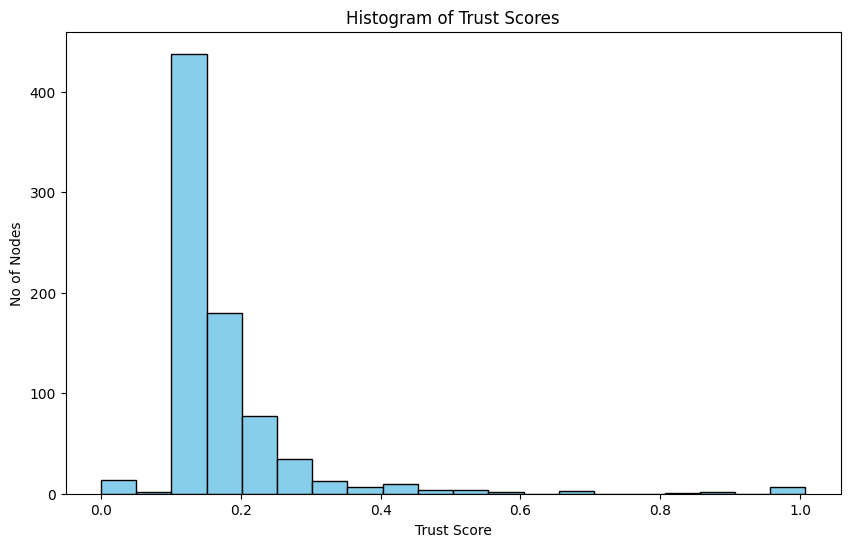

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(results_df["Trust_Score"], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Trust Scores")
plt.xlabel("Trust Score")
plt.ylabel("No of Nodes")
plt.savefig("trustScore_histogram.png")
plt.show()